In [1]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!cp '/content/gdrive/My Drive/Medios continuos/ezweb_17590.zip' 'sol'

In [ ]:
!unzip sol

##2) 
Descargar los datos del Sol durante toda su vida (debe dejar en blanco la casilla "Maximum age").  Haga un gráfico del logaritmo del radio como función del tiempo e identifique el momento en el que el Sol se volverá 10 veces más grande que el sol actual.  Repita el análisis en 1 para la estructura del Sol en esa etapa de su vida.

In [4]:
datos1=np.loadtxt("summary.txt")

Los datos globales de la estrella en cada paso de integración están en el archivo `summary.txt` con las siguientes columnas:

In [5]:
"""
1	i	Step number
2	t	Age (years)
3	M	Mass (M☉)
4	Log10 L	Luminosity (L☉)
5	Log10 R	Radius (R☉)
6	Log10 Ts	Surface temperature (K)
7	Log10 Tc	Central temperature (K)
8	Log10 ρc	Central density (kg m-3)
9	Log10 Pc	Central pressure (N m-2)
10	ψc	Central electron degeneracy parameter
11	Xc	Central hydrogen mass fraction
12	Yc	Central helium mass fraction
13	XC,c	Central carbon mass fraction
14	XN,c	Central nitrogen mass fraction
15	XO,c	Central oxygen mass fraction
16	τdyn	Dynamical timescale (seconds)
17	τKH	Kelvin-Helmholtz timescale (years)
18	τnuc	Nuclear timescale (years)
19	LPP	Luminosity from PP chain (L☉)
20	LCNO	Luminosity from CNO cycle (L☉)
21	L3α	Luminosity from triple-alpha reactions (L☉)
22	LZ	Luminosity from metal burning (L☉)
23	Lν	Luminosity of neutrino losses (L☉)
24	MHe	Mass of helium core (M☉)
25	MC	Mass of carbon core (M☉)
26	MO	Mass of oxygen core (M☉)
27	RHe	Radius of helium core (R☉)
28	RC	Radius of carbon core (R☉)
29	RO	Radius of oxygen core (R☉)
""";

In [6]:
Tiempo=datos1[:,1]
LogR=datos1[:,4]

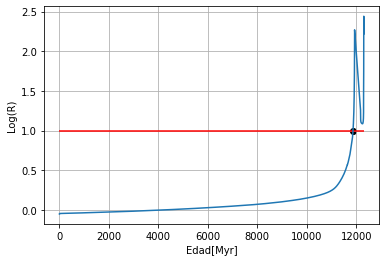

In [7]:
plt.plot(Tiempo/1e6,LogR) #conversión a mega años
plt.hlines(1,0,max(Tiempo/1e6), color='red') #log(10 radios solares) = 1
plt.scatter(Tiempo[350]/1e6,1,color='k',marker='o',linewidths=1)
plt.ylabel('Log(R)')
plt.xlabel('Edad[Myr]')
plt.grid()

In [8]:
print("El sol se volverá 10 veces más grande a la edad de" ,Tiempo[350],"años")

El sol se volverá 10 veces más grande a la edad de 11866530300.0 años


In [9]:
XH=datos1[:,10][350] #Fración de masa del hidrógeno 
YHe=datos1[:,11][350] #Fracción de masa del helio
Masa=datos1[:,2][350] #Masa en dicho tiempo
Radio=10**(datos1[:,4][350]) #Radio en ese tiempo

In [10]:
datos=np.loadtxt("structure_00350.txt") 
Mrs=datos[:,0]
rs=datos[:,1]
ps=datos[:,3]
rhos=datos[:,4]
Ts=datos[:,5]
cps=datos[:,8]

In [11]:
logTs=np.log(Ts)
logps=np.log(ps)
gamma_effs=1/(1-((logTs[1:]-logTs[:-1])/(logps[1:]-logps[:-1]))) #calculamos el coeficiente adiabático efectivo 
gamma_prom=np.mean(gamma_effs)

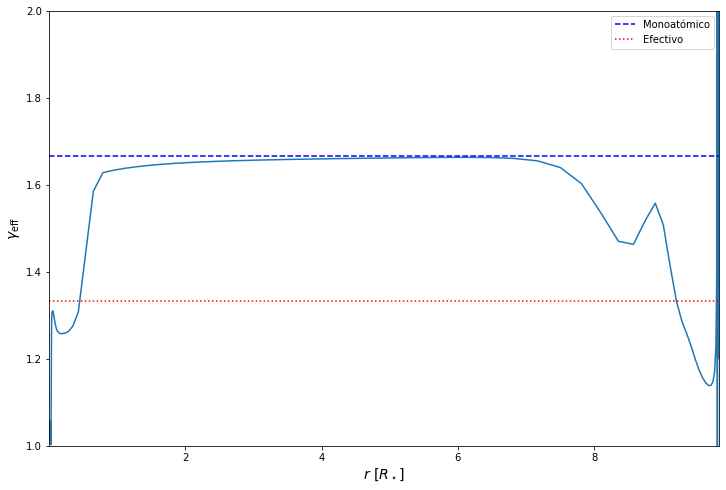

In [12]:
#graficacion del gama efectivo
fig,ax=plt.subplots(figsize=(12,8))
ax.plot(rs[:-1],gamma_effs)
ax.set_ylim(1,2)
ax.axhline(5/3,label="Monoatómico",color='b',ls="--")
ax.axhline(4/3,label="Efectivo",color='r',ls=":")
ax.legend()
ax.set_ylabel(r"$\gamma_{\rm eff}$",fontsize=14)
ax.set_xlabel(r"$r$ [$R_\star$]",fontsize=14)
ax.margins(0)

In [13]:
#Ecuacion de lambert
def lane_emden(Y,x,gamma=5/3):
  teta,tetap=Y

  dtetadr=tetap
  dtetapdr=-2/x*tetap-teta**(1/(gamma-1))

  return np.array([dtetadr,dtetapdr])

In [14]:
#comparacion con el modelo realista
#Asumimiendo
gamma_eff=1.205
xs=np.linspace(1e-2,120,1000)
Yo=[1,0]
solucion=odeint(lane_emden,Yo,xs,args=(gamma_eff,))
teta=solucion[:,0]
tetap=solucion[:,1]
xo=xs[np.invert(np.isnan(teta))][-1]
tetapo=tetap[np.invert(np.isnan(teta))][-1]
print(xo,tetapo)


120.0 -0.00011971713712849162


In [15]:
G=6.67e-11
Rsol=6.96349e8
#Propiedades de la estrella
Rsun=Radio*6.96349e8 #m
Msun=Masa*1.98e30 #kg
rho0=Msun/(4/3*np.pi*Rsun**3)
go=G*Msun/Rsun**2
#Masa molar
X=XH
Y=YHe
Z=1-X-Y
Mmol=4/(3+5*X-Z)*1e-3 #kg/mol
R=8.31446261815324 #J/kg/mol
#Calor específico
cp=gamma_eff/(gamma_eff-1)*R/Mmol
#Condiciones centrales
To=go*Rsun/cp
Tc=To/(-tetapo*xo)
rhoc=rho0*xo**2*Tc/(3*To)
Pc=ps[-1]
print(f"Temperatura central {Tc}")
print(f"Densidad central {rhoc}")
print(f"Presión central {Pc}")
#Lambda
lamb=np.sqrt(cp*Tc/(4*np.pi*G*rhoc))
print(f"Lambda = {lamb/1e3} km")
#Finalmente las condiciones son
rs_sun=xs*lamb
Ts_sun=teta*Tc

rhos_sun=rhoc*teta**(1/(gamma_eff-1))

Ps_sun=Pc*teta**(gamma_eff/(gamma_eff-1))

Temperatura central 36722608.93295938
Densidad central 490258.7648652293
Presión central 1.84165868e+21
Lambda = 57042.417795895926 km


## Perfil de Temperatura

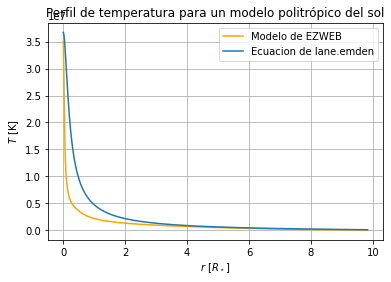

In [16]:
plt.plot(rs,Ts,color="orange",label="Modelo de EZWEB")
plt.plot(rs_sun/Rsol,Ts_sun,label="Ecuacion de lane.emden")
plt.ylabel(r"$T$ [K]")
plt.xlabel(r"$r$ [$R_\star$]")
plt.title("Perfil de temperatura para un modelo politrópico del sol")
plt.legend()
plt.grid()

## Perfil de densidad

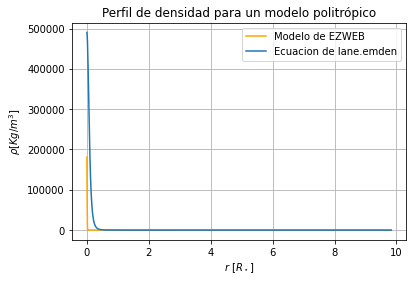

In [17]:
plt.plot(rs,rhos,color="orange",label="Modelo de EZWEB")
plt.plot(rs_sun/Rsol,rhos_sun,label="Ecuacion de lane.emden")
plt.ylabel(r"$\rho [Kg/m^3]$")
plt.xlabel(r"$r$ [$R_\star$]")
plt.title("Perfil de densidad para un modelo politrópico")
plt.legend()
plt.grid()

## Perfil de Presión


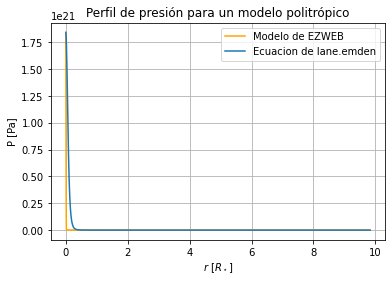

In [18]:
plt.plot(rs,ps,color="orange",label="Modelo de EZWEB")
plt.plot(rs_sun/Rsol,Ps_sun,label="Ecuacion de lane.emden")
plt.ylabel('P [Pa]')
plt.xlabel(r"$r$ [$R_\star$]")
plt.title("Perfil de presión para un modelo politrópico")
plt.legend()
plt.grid()